# Analisis de artifact comparison

Este notebook carga `../artifacts/artifact_comparison.json`, resume los mejores runs y genera graficas para estudiar que hiperparametros funcionan mejor.

In [2]:
import json
from pathlib import Path
from statistics import mean, pstdev

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "analysis" else Path.cwd().resolve()
INPUT_PATH = ROOT_DIR / "artifacts" / "artifact_comparison.json"
OUTPUT_DIR = ROOT_DIR / "analysis" / "artifact_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HYPERPARAMS = [
    "vocab_size",
    "seq_len",
    "dim_embedding",
    "dim_attention",
    "num_heads",
    "num_layers",
]
PRIMARY_METRIC = "bits_per_char"

In [3]:
payload = json.loads(INPUT_PATH.read_text(encoding="utf-8"))
results = payload.get("results", [])
if not results:
    raise ValueError(f"No hay resultados en {INPUT_PATH}")

df = pd.DataFrame(results).sort_values(PRIMARY_METRIC).reset_index(drop=True)
df["run_name"] = df["run_dir"].map(lambda path: Path(path).name)

print(f"Runs evaluados: {len(df)}")
print(f"Runs saltados: {len(payload.get('skipped', []))}")
print(f"Mejor run: {df.iloc[0]['run_name']}")
print(f"Mejor bits_per_char: {df.iloc[0][PRIMARY_METRIC]:.6f}")

df.head()

Runs evaluados: 264
Runs saltados: 0
Mejor run: 20260424-063939
Mejor bits_per_char: 124.976679


,run_dir,vocab_size,seq_len,dim_embedding,dim_attention,num_heads,num_layers,batch_size,epochs,learning_rate,...,tokens_per_char,unk_rate,nll_per_token,token_perplexity,nll_per_char,bits_per_char,best_epoch,saved_val_loss,saved_perplexity,run_name
0,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,256,64,128,80,2,2,-1,-1,None,...,0.459390,0.0,2.960134,19.300563,86.627233,124.976679,2,2.9622,19.34,20260424-063939
1,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,256,64,128,256,2,2,-1,-1,None,...,0.459390,0.0,2.961022,19.317701,86.653207,125.014152,2,2.9635,19.37,20260424-071421
2,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,350,64,128,128,2,2,-1,-1,None,...,0.415352,0.0,3.278787,26.543561,86.711381,125.098079,2,3.2869,26.76,20260424-114001
3,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,350,64,128,80,2,2,-1,-1,None,...,0.415352,0.0,3.283891,26.679379,86.846356,125.292807,2,3.2904,26.85,20260424-112803
4,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,128,64,128,256,2,2,-1,-1,None,...,0.585946,0.0,2.325207,10.228799,86.879561,125.340712,2,2.3260,10.24,20260424-012225


## Resumen del mejor modelo

In [4]:
best_run = df.iloc[0]
best_run[[
    "run_name",
    "bits_per_char",
    "token_perplexity",
    "vocab_size",
    "seq_len",
    "dim_embedding",
    "dim_attention",
    "num_heads",
    "num_layers",
]]

run_name            20260424-063939
bits_per_char            124.976679
token_perplexity          19.300563
vocab_size                      256
seq_len                          64
dim_embedding                   128
dim_attention                    80
num_heads                         2
num_layers                        2
Name: 0, dtype: object

## Top runs

In [5]:
top_n = 15
top_runs = df.head(top_n).copy()
top_runs[[
    "run_name",
    "bits_per_char",
    "token_perplexity",
    "vocab_size",
    "seq_len",
    "dim_embedding",
    "dim_attention",
    "num_heads",
    "num_layers",
]]

,run_name,bits_per_char,token_perplexity,vocab_size,seq_len,dim_embedding,dim_attention,num_heads,num_layers
0,20260424-063939,124.976679,19.300563,256,64,128,80,2,2
1,20260424-071421,125.014152,19.317701,256,64,128,256,2,2
2,20260424-114001,125.098079,26.543561,350,64,128,128,2,2
3,20260424-112803,125.292807,26.679379,350,64,128,80,2,2
4,20260424-012225,125.340712,10.228799,128,64,128,256,2,2
5,20260424-005845,125.691016,10.295488,128,64,128,128,2,2
6,20260424-065631,125.708978,19.638249,256,64,128,128,2,2
7,20260424-115146,125.771660,27.016331,350,64,128,256,2,2
8,20260424-003623,125.858871,10.327597,128,64,128,80,2,2
9,20260424-062522,126.433444,19.978136,256,64,64,256,2,2


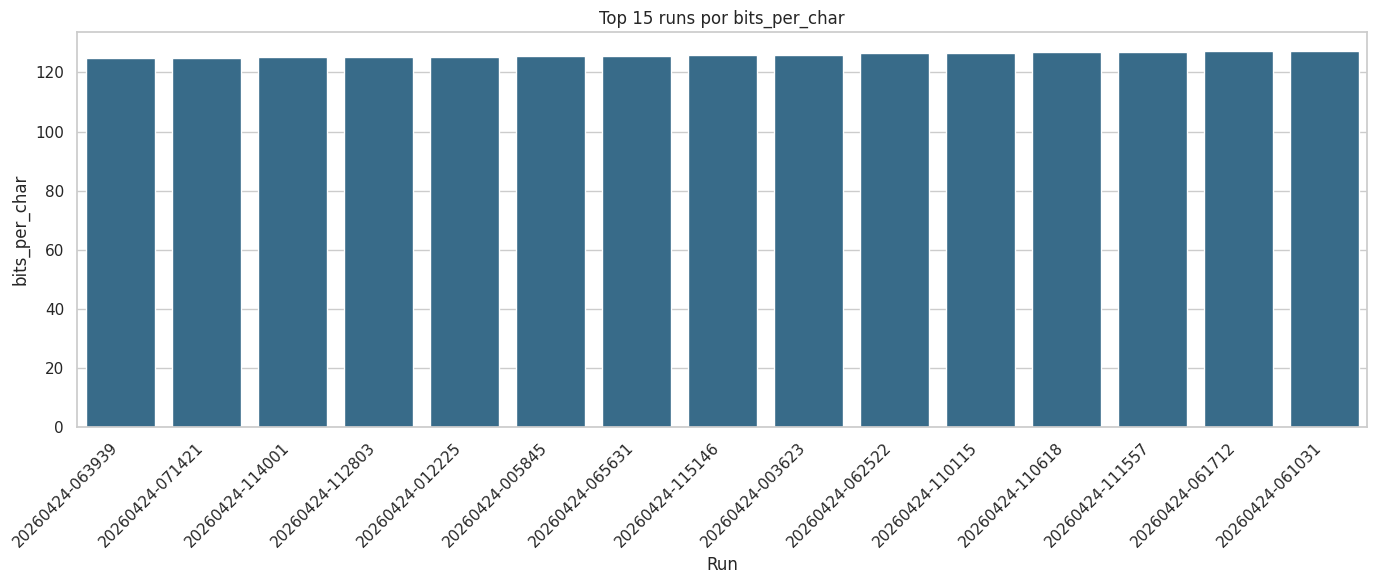

In [6]:
plt.figure(figsize=(14, 6))
sns.barplot(data=top_runs, x="run_name", y=PRIMARY_METRIC, color="#2a6f97")
plt.xticks(rotation=45, ha="right")
plt.title(f"Top {top_n} runs por {PRIMARY_METRIC}")
plt.xlabel("Run")
plt.ylabel(PRIMARY_METRIC)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_runs.png", dpi=180)
plt.show()

## Impacto de cada hiperparametro

In [7]:
impact_rows = []
for param in HYPERPARAMS:
    grouped = df.groupby(param)[PRIMARY_METRIC].agg(["mean", "std", "min", "max", "count"]).reset_index()
    grouped = grouped.sort_values("mean")
    best_group = grouped.iloc[0]
    worst_group = grouped.iloc[-1]
    impact_rows.append({
        "param": param,
        "impact_range": worst_group["mean"] - best_group["mean"],
        "best_value": best_group[param],
        "best_mean_metric": best_group["mean"],
        "worst_value": worst_group[param],
        "worst_mean_metric": worst_group["mean"],
    })

impact_df = pd.DataFrame(impact_rows).sort_values("impact_range", ascending=False)
impact_df

,param,impact_range,best_value,best_mean_metric,worst_value,worst_mean_metric
1,seq_len,2417.084426,64.0,136.941210,1024.0,2554.025636
0,vocab_size,2353.369148,1000.0,200.656487,6597.0,2554.025636
4,num_heads,2347.027111,2.0,206.998525,8.0,2554.025636
5,num_layers,2346.987348,1.0,207.038288,4.0,2554.025636
2,dim_embedding,73.474912,64.0,198.458588,128.0,271.933499
3,dim_attention,69.023332,80.0,198.518976,256.0,267.542308


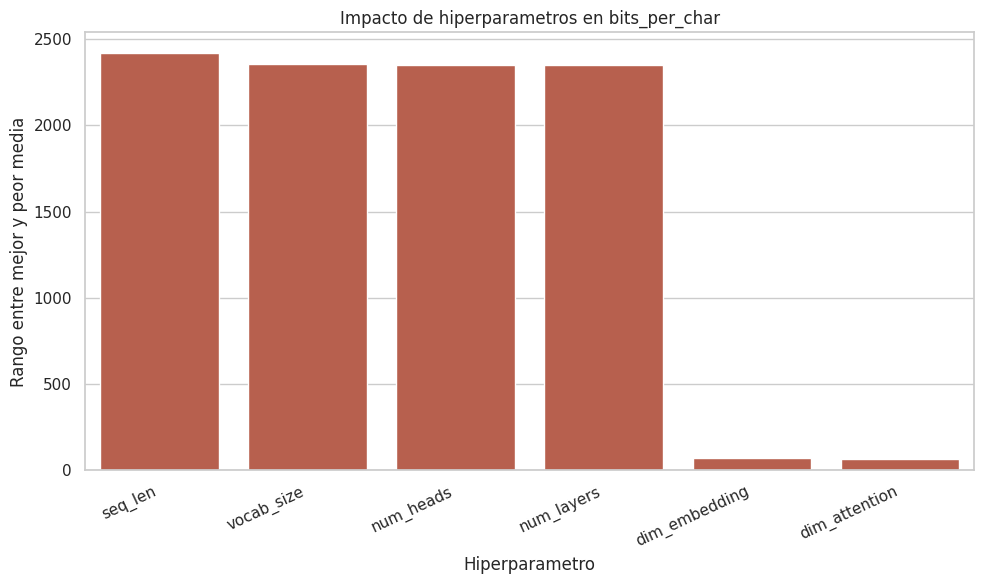

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=impact_df, x="param", y="impact_range", color="#c8553d")
plt.xticks(rotation=25, ha="right")
plt.title(f"Impacto de hiperparametros en {PRIMARY_METRIC}")
plt.xlabel("Hiperparametro")
plt.ylabel("Rango entre mejor y peor media")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "param_impact.png", dpi=180)
plt.show()

## Analisis por hiperparametro

,vocab_size,mean,std,min,max,count
6,1000,200.656487,66.413104,129.457032,275.212943,32
4,350,202.802209,74.264195,125.098079,358.047299,36
2,128,206.193712,60.341851,125.340712,322.902161,54
3,256,206.265670,73.582124,124.976679,351.530573,73
5,512,209.466893,70.256962,132.755006,287.110927,32
1,95,221.381798,33.051521,187.509067,256.558216,18
0,64,223.020859,32.498586,189.827895,255.993479,18
7,6597,2554.025636,NaN,2554.025636,2554.025636,1


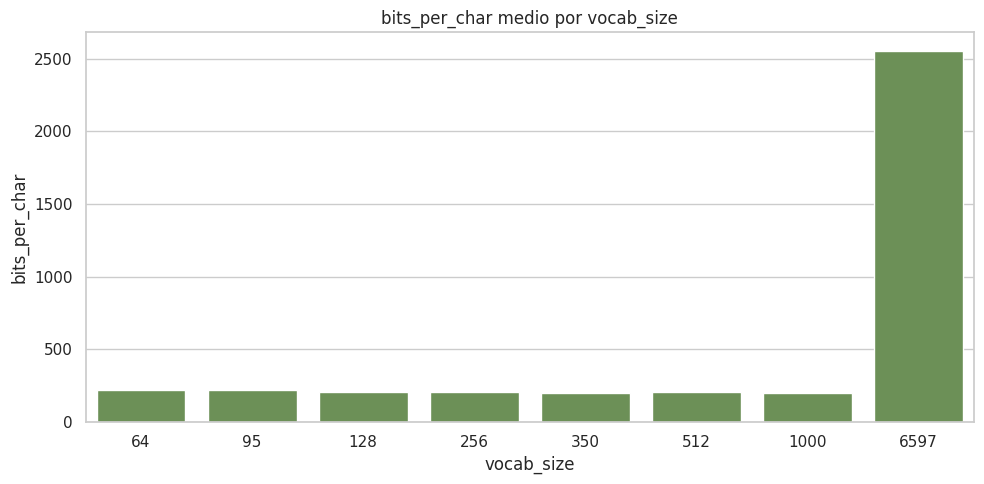

,seq_len,mean,std,min,max,count
0,64,136.941210,9.539352,124.976679,160.426156,107
1,96,189.992344,1.647982,187.485549,193.058839,27
2,128,270.026567,21.196873,248.488434,358.047299,129
3,1024,2554.025636,NaN,2554.025636,2554.025636,1


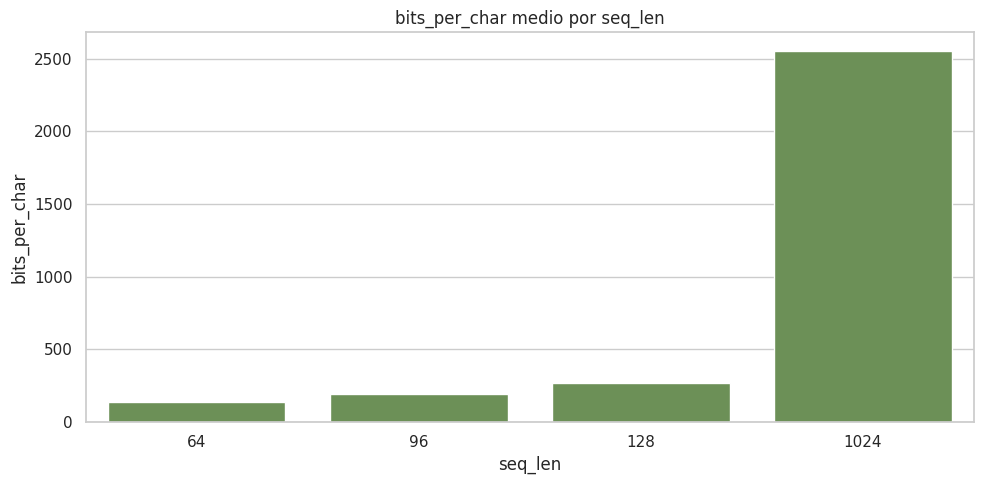

,dim_embedding,mean,std,min,max,count
2,64,198.458588,67.619539,126.433444,300.437287,84
1,40,202.056630,69.333867,127.275942,289.508609,36
0,32,211.221079,72.109386,133.018364,311.679943,53
6,140,220.863621,32.701419,187.485549,255.216519,18
4,105,221.034590,32.438564,187.509067,255.195979,18
3,70,223.053948,32.728551,188.915326,257.687281,18
5,128,271.933499,393.458780,124.976679,2554.025636,37


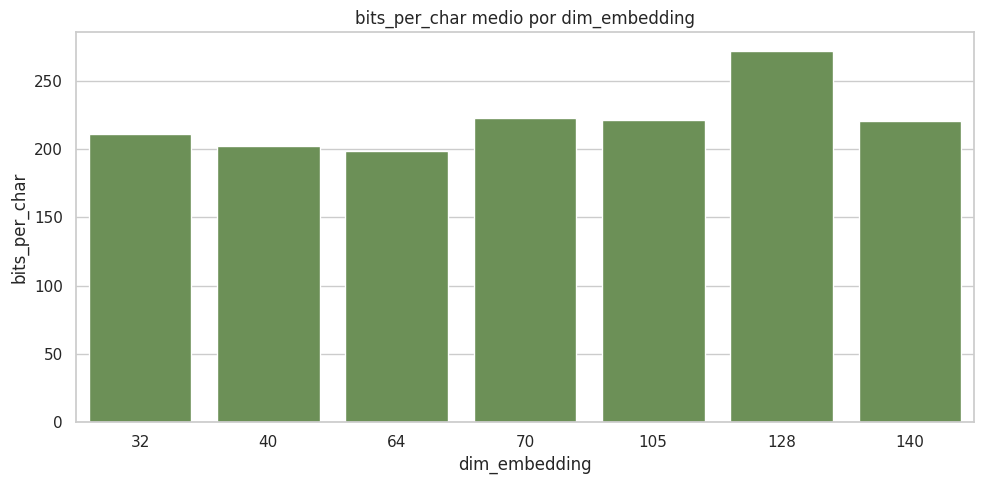

,dim_attention,mean,std,min,max,count
1,80,198.518976,69.323105,124.976679,298.805099,36
0,64,205.052182,70.631186,129.711416,311.679943,53
2,128,205.801220,70.758120,125.098079,327.461012,84
3,140,221.099695,32.568219,187.485549,257.687281,18
4,210,221.621816,32.619613,187.568622,256.558216,18
6,280,222.230648,32.719069,188.555521,255.614549,18
5,256,267.542308,393.473048,125.014152,2554.025636,37


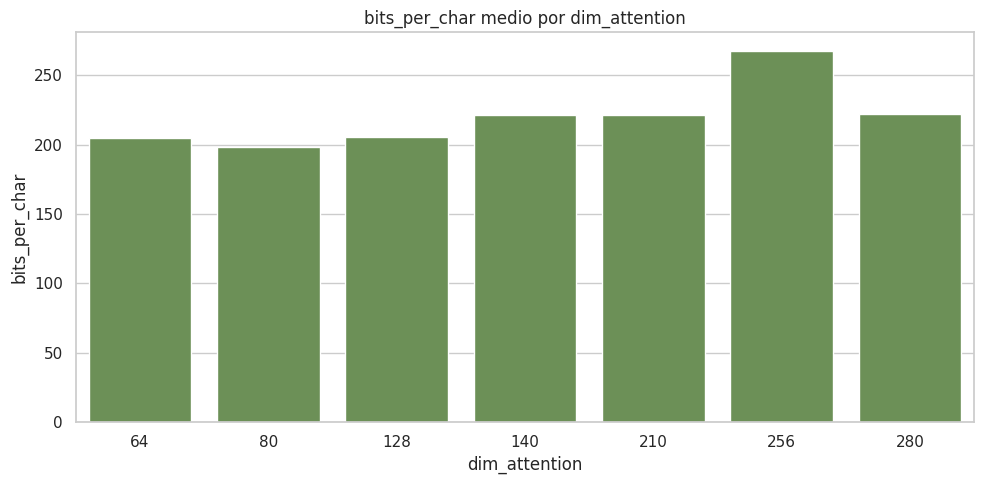

,num_heads,mean,std,min,max,count
0,2,206.998525,63.882970,124.976679,358.047299,215
1,4,210.650980,71.260805,129.723530,311.679943,48
2,8,2554.025636,NaN,2554.025636,2554.025636,1


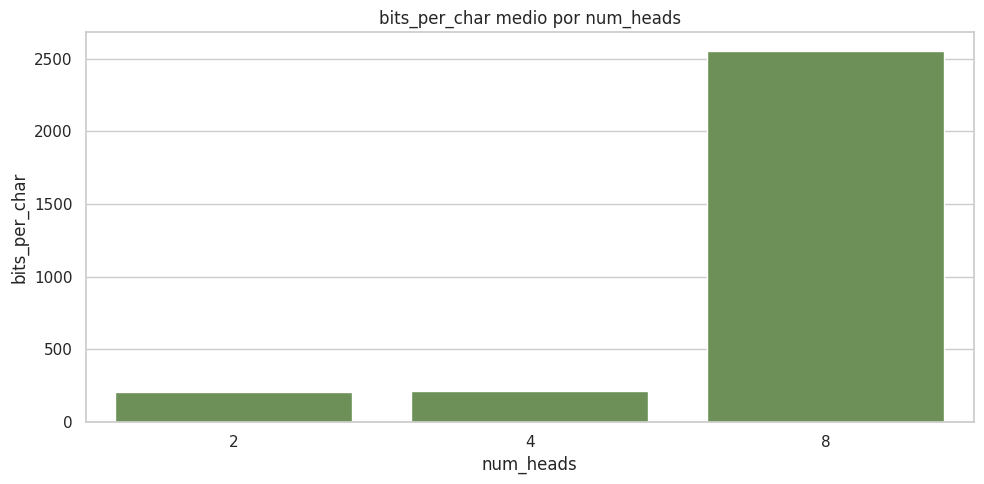

,num_layers,mean,std,min,max,count
0,1,207.038288,71.392578,131.976695,311.679943,53
1,2,207.823336,63.677966,124.976679,358.047299,210
2,4,2554.025636,NaN,2554.025636,2554.025636,1


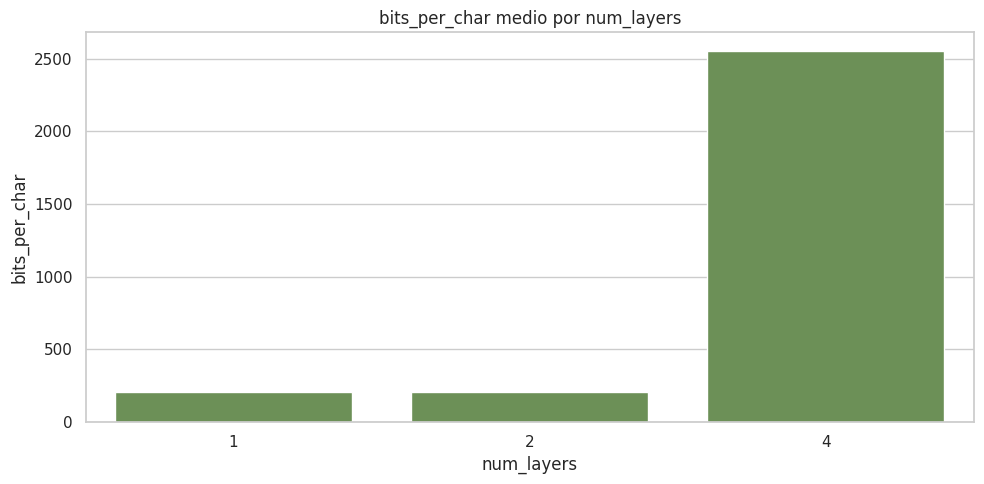

In [9]:
grouped_stats = {}
for param in HYPERPARAMS:
    stats = df.groupby(param)[PRIMARY_METRIC].agg(["mean", "std", "min", "max", "count"]).reset_index()
    stats = stats.sort_values("mean")
    grouped_stats[param] = stats
    display(stats)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=stats, x=param, y="mean", color="#6a994e")
    plt.title(f"{PRIMARY_METRIC} medio por {param}")
    plt.xlabel(param)
    plt.ylabel(PRIMARY_METRIC)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"metric_by_{param}.png", dpi=180)
    plt.show()

## Relaciones entre dimensiones y calidad

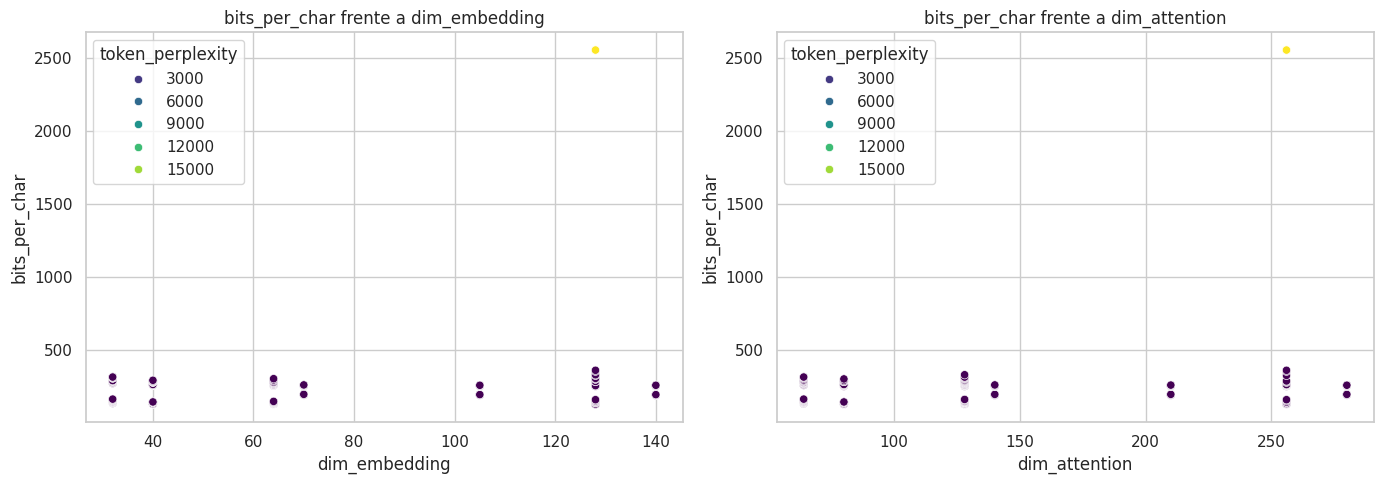

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x="dim_embedding",
    y=PRIMARY_METRIC,
    hue="token_perplexity",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("bits_per_char frente a dim_embedding")

sns.scatterplot(
    data=df,
    x="dim_attention",
    y=PRIMARY_METRIC,
    hue="token_perplexity",
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("bits_per_char frente a dim_attention")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_dimensions_vs_bpc.png", dpi=180)
plt.show()

## Heatmaps

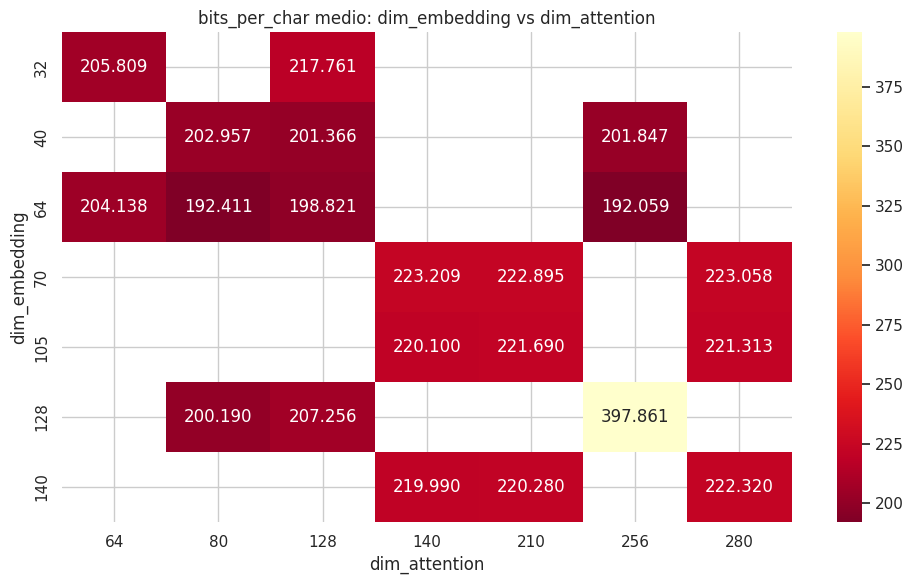

In [11]:
pivot_embedding_attention = df.pivot_table(
    values=PRIMARY_METRIC,
    index="dim_embedding",
    columns="dim_attention",
    aggfunc="mean",
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_embedding_attention, annot=True, fmt=".3f", cmap="YlOrRd_r")
plt.title(f"{PRIMARY_METRIC} medio: dim_embedding vs dim_attention")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heatmap_embedding_attention.png", dpi=180)
plt.show()

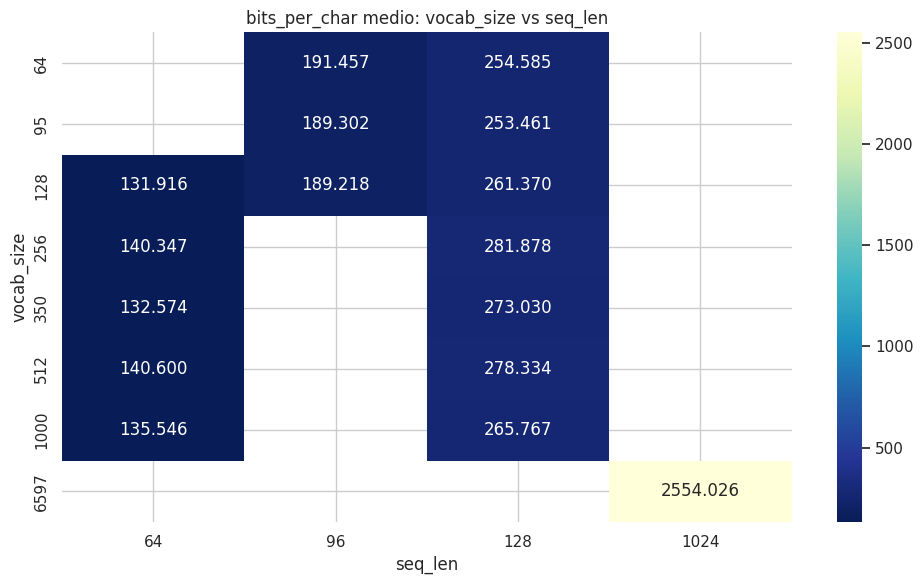

In [12]:
pivot_vocab_seq = df.pivot_table(
    values=PRIMARY_METRIC,
    index="vocab_size",
    columns="seq_len",
    aggfunc="mean",
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_vocab_seq, annot=True, fmt=".3f", cmap="YlGnBu_r")
plt.title(f"{PRIMARY_METRIC} medio: vocab_size vs seq_len")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heatmap_vocab_seq_len.png", dpi=180)
plt.show()

## Recomendacion de hiperparametros

In [13]:
recommendation = {}
for param in HYPERPARAMS:
    grouped = df.groupby(param)[PRIMARY_METRIC].mean().sort_values()
    recommendation[param] = grouped.index[0]

recommendation

{'vocab_size': np.int64(1000),
 'seq_len': np.int64(64),
 'dim_embedding': np.int64(64),
 'dim_attention': np.int64(80),
 'num_heads': np.int64(2),
 'num_layers': np.int64(1)}

In [14]:
summary_lines = [
    "# Analisis de artifact comparison",
    "",
    f"- Runs evaluados: {len(df)}",
    f"- Runs saltados: {len(payload.get('skipped', []))}",
    f"- Mejor run: {best_run['run_name']}",
    f"- Mejor bits_per_char: {best_run[PRIMARY_METRIC]:.6f}",
    f"- Mejor token_perplexity: {best_run['token_perplexity']:.6f}",
    "",
    "## Recomendacion por media de hiperparametro",
    "",
]

for key, value in recommendation.items():
    summary_lines.append(f"- {key}: {value}")

(OUTPUT_DIR / "summary.md").write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
impact_df.to_json(OUTPUT_DIR / "impact_by_param.json", orient="records", force_ascii=False, indent=2)
print(f"Resumen guardado en {OUTPUT_DIR / 'summary.md'}")
print(f"Graficas guardadas en {OUTPUT_DIR}")

Resumen guardado en /home/hegarc04/pln/fdi-pln-2602/p5/analysis/artifact_analysis/summary.md
Graficas guardadas en /home/hegarc04/pln/fdi-pln-2602/p5/analysis/artifact_analysis
